## Import necessary libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score
from sklearn.ensemble import GradientBoostingRegressor
!pip install xgboost
from xgboost import XGBRegressor


## Load the dataset

In [52]:
data = pd.read_csv("Housing.csv")
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## EDA (Exploratory Data Analysis)

In [53]:
print("Dataset Info:\n")
print(data.info())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


# Check for missing values

In [54]:
print("\nMissing Values in Each Column:\n")
print(data.isnull().sum())


Missing Values in Each Column:

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# Display basic statistics

In [55]:
print("\nStatistical Summary:\n")
print(data.describe())



Statistical Summary:

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [32]:
data["furnishingstatus"].value_counts()

semi-furnished    227
unfurnished       178
furnished         140
Name: furnishingstatus, dtype: int64

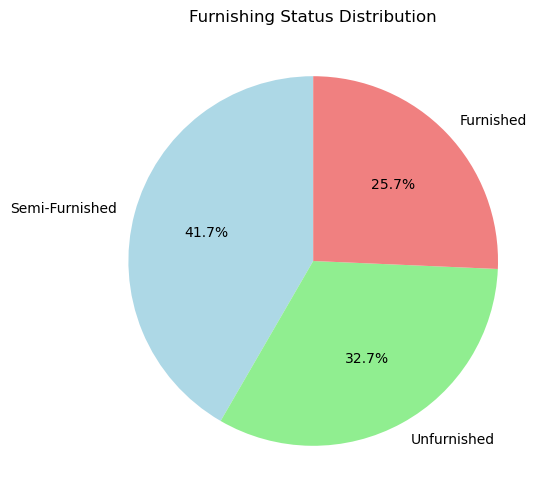

In [33]:
import matplotlib.pyplot as plt

# Data
labels = ['Semi-Furnished', 'Unfurnished', 'Furnished']
sizes = [227, 178, 140]

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('Furnishing Status Distribution')
plt.show()

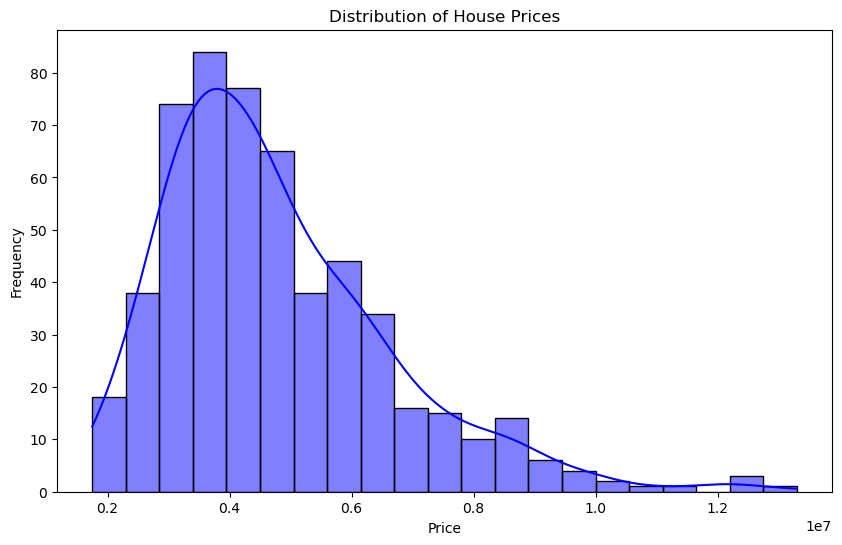

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

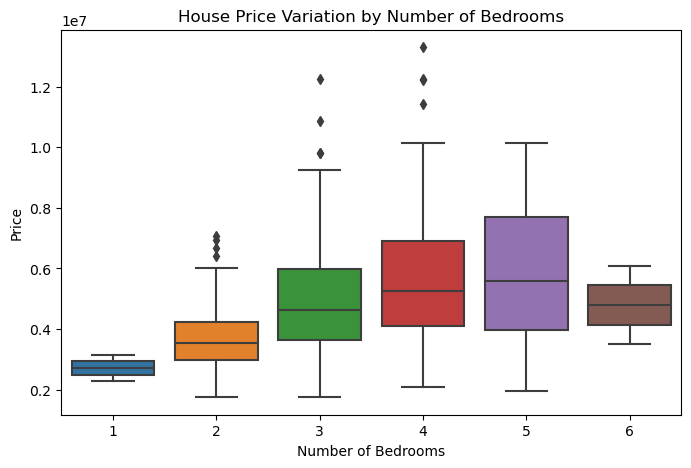

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='bedrooms', y='price', data=data)
plt.title('House Price Variation by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

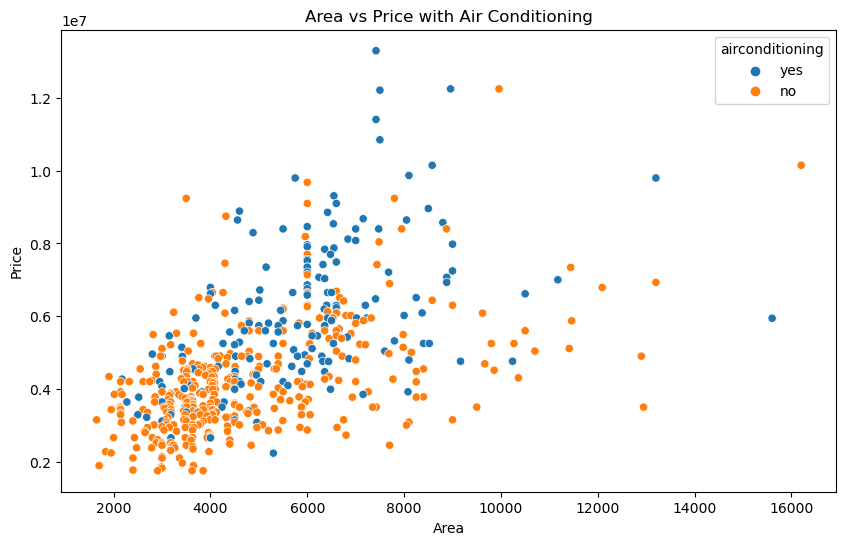

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', hue='airconditioning', data=data)
plt.title('Area vs Price with Air Conditioning')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

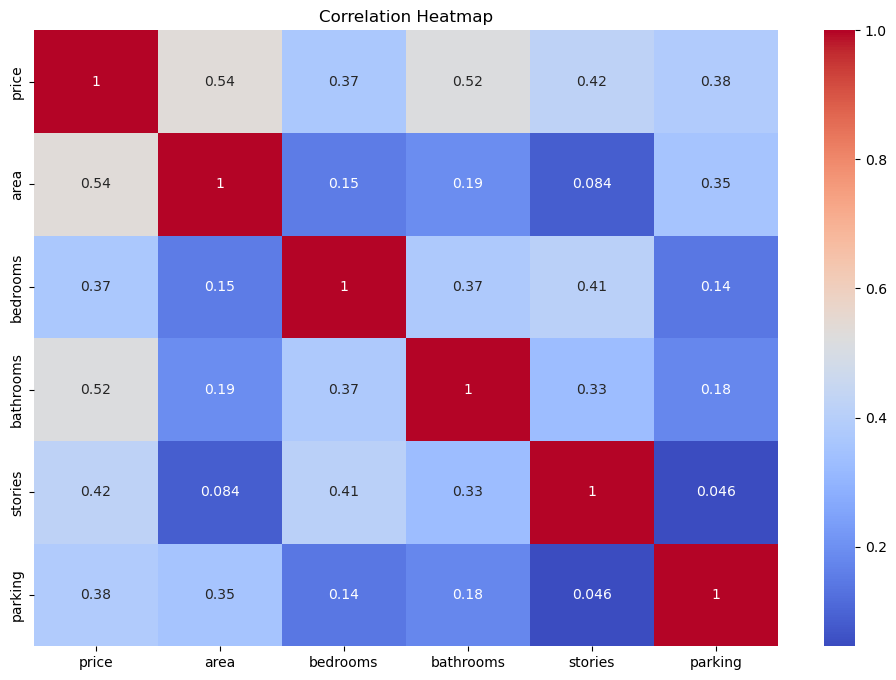

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



In [42]:
print("Air Conditioning Value Counts:")
print(data['airconditioning'].value_counts())
print("\nMain Road Value Counts:")
print(data['mainroad'].value_counts())

Air Conditioning Value Counts:
no     373
yes    172
Name: airconditioning, dtype: int64

Main Road Value Counts:
yes    468
no      77
Name: mainroad, dtype: int64


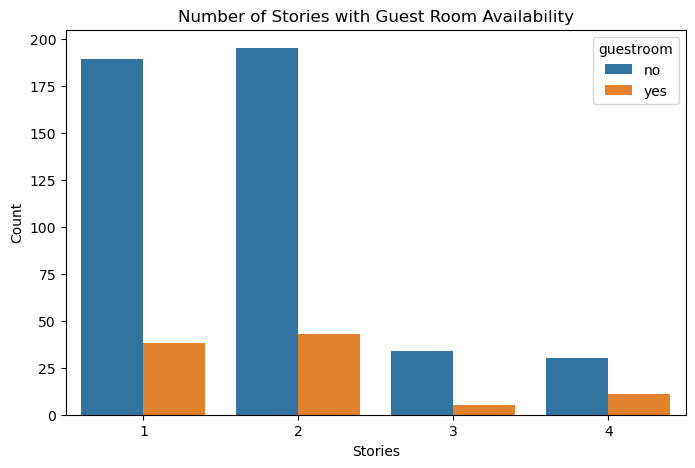

In [43]:
plt.figure(figsize=(8, 5))
sns.countplot(x='stories', hue='guestroom', data=data)
plt.title('Number of Stories with Guest Room Availability')
plt.xlabel('Stories')
plt.ylabel('Count')
plt.show()

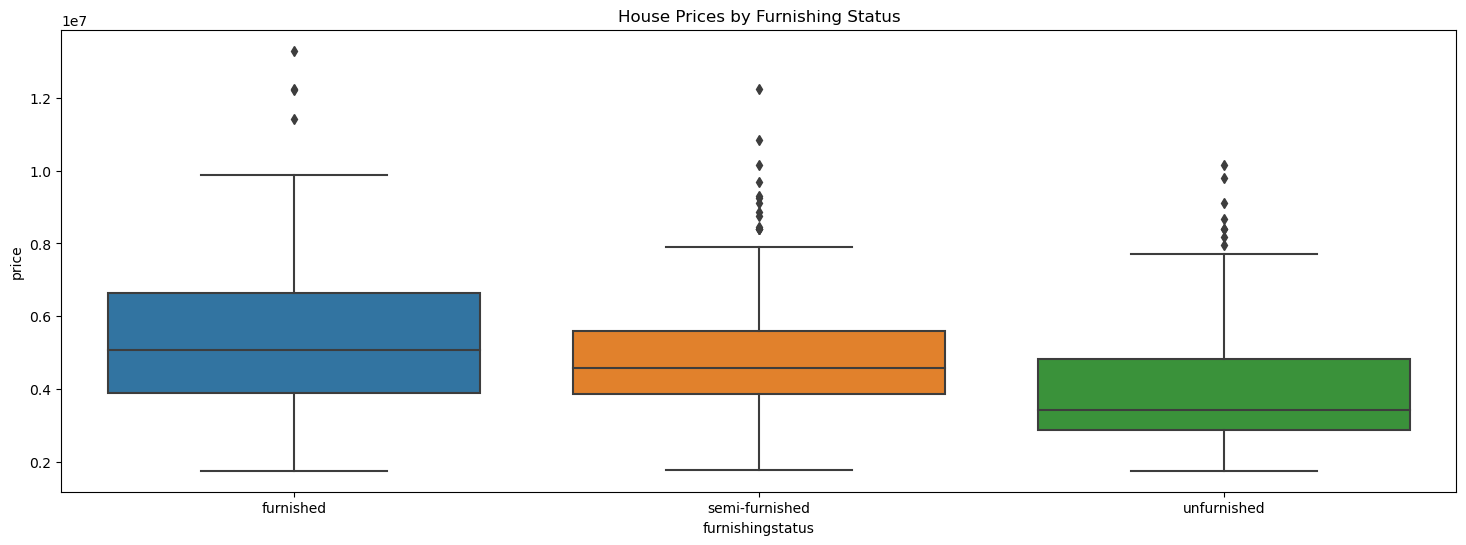

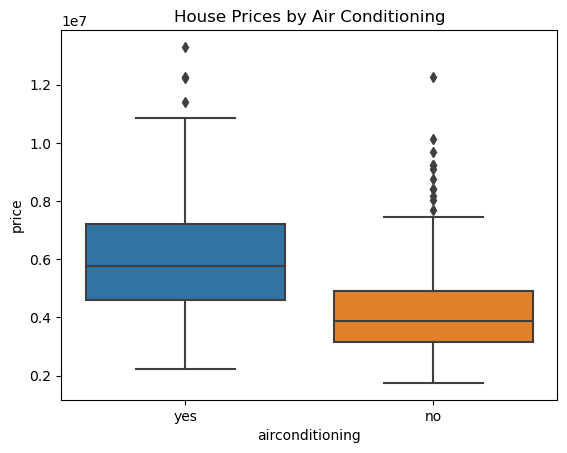

In [19]:
plt.figure(figsize=(18, 6))
sns.boxplot(x='furnishingstatus', y='price', data=data)
plt.title('House Prices by Furnishing Status')
plt.show()

sns.boxplot(x='airconditioning', y='price', data=data)
plt.title('House Prices by Air Conditioning')
plt.show()



# Data Preprocessing
# Encode categorical variables using Label Encoding


In [56]:
label_encoder = LabelEncoder()
categorical_columns = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning',
    'prefarea', 'furnishingstatus'
]

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])



# Separate features and target variable

In [98]:
X = data.drop('price', axis=1)
y = data['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [99]:
# Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression - MSE:", mse_lr, "R^2:", r2_lr,"MAE:",mae_lr)


Linear Regression - MSE: 1771751116594.041 R^2: 0.6494754192267792 MAE: 979679.6912959908


In [100]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Model
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)

# Evaluation
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print("Decision Tree - MSE:", mse_tree, "R^2:", r2_tree,"MAE:",mae_tree)


Decision Tree - MSE: 2688177649082.569 R^2: 0.4681689010023007 MAE: 1222399.0825688073


In [101]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, y_train)
y_pred_forest = forest_reg.predict(X_test)

# Evaluation
mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)
print("Random Forest - MSE:", mse_forest, "R^2:", r2_forest,"MAE:",mae_forest)


Random Forest - MSE: 1962144940711.022 R^2: 0.6118077610803518 MAE: 1026699.6876146789


In [102]:
### 2. XGBoost Regressor Model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)


print("XGBoost - R² Score:", r2_xgb , "MSE:", mse_xgb, "MAE:",mae_xgb)

XGBoost - R² Score: 0.5979075332022226 MSE: 2032404618961.4353 MAE: 1062315.9931192661


In [106]:
# Initialize and train the Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Calculate performance metrics
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)

# Print the performance metrics
print("Gradient Boosting Regressor - R2 Score:",r2_gb , "MSE:", mse_gb, "MAE:", mae_gb)

Gradient Boosting Regressor - R2 Score: 0.6646855642239725 MSE: 1694870370248.4102 MAE: 964058.8730464154


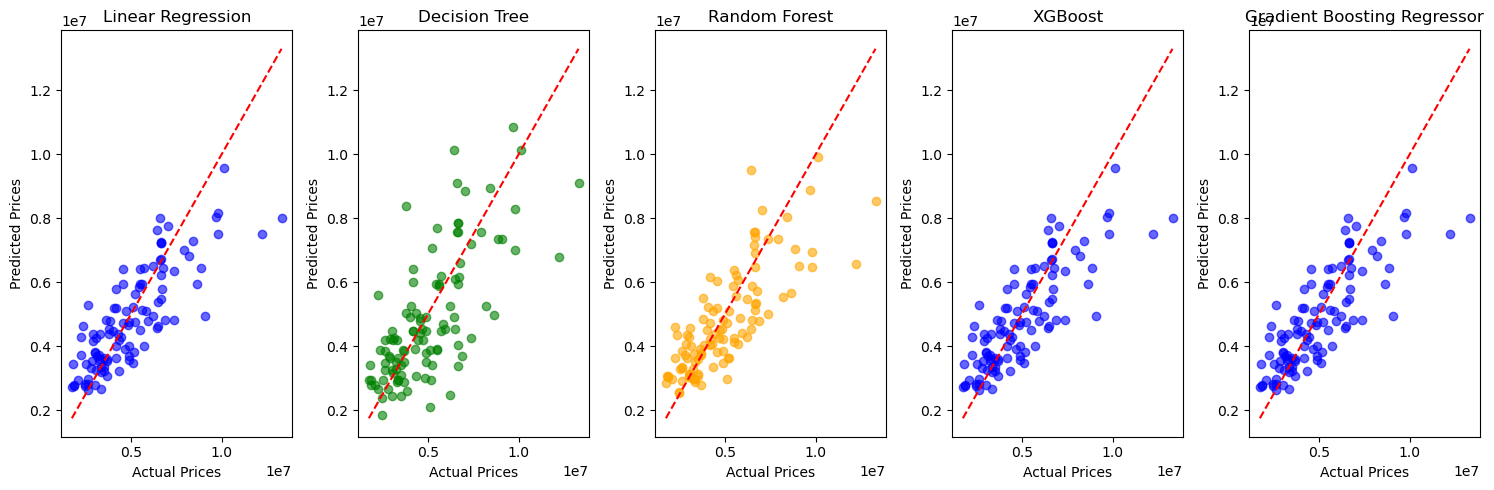

In [108]:
# Plotting
plt.figure(figsize=(15, 5))

# Linear Regression
plt.subplot(1, 5, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
plt.title("Linear Regression")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# Decision Tree
plt.subplot(1, 5, 2)
plt.scatter(y_test, y_pred_tree, alpha=0.6, color='green')
plt.title("Decision Tree")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# Random Forest
plt.subplot(1, 5, 3)
plt.scatter(y_test, y_pred_forest, alpha=0.6, color='orange')
plt.title("Random Forest")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# XGBoost
plt.subplot(1, 5, 4)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
plt.title("XGBoost")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

# Gradient Boosting Regressor
plt.subplot(1, 5, 5)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
plt.title("Gradient Boosting Regressor")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.tight_layout()
plt.show()


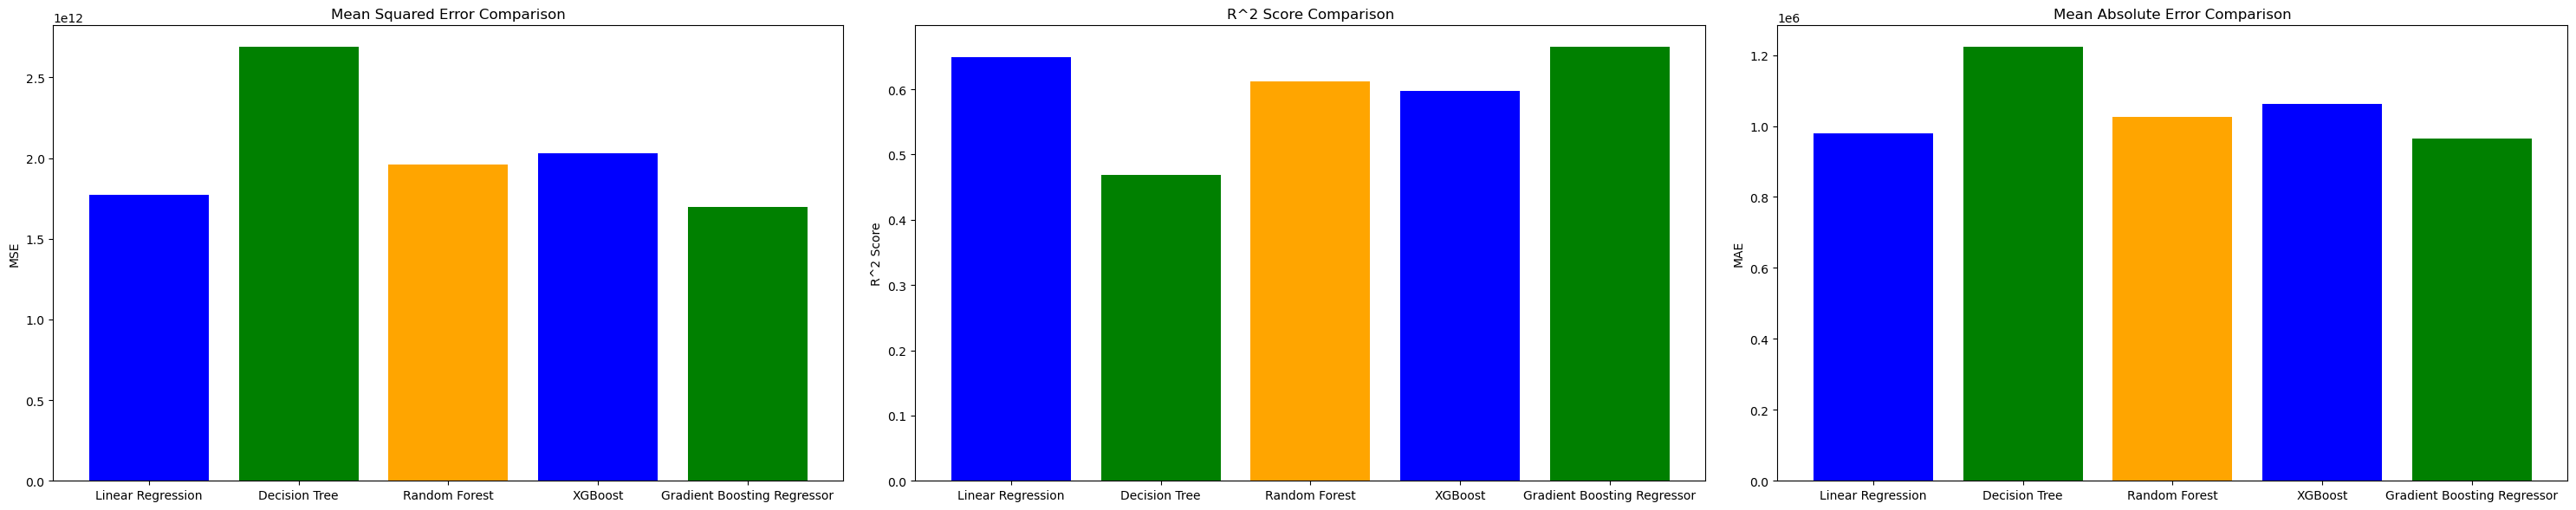

In [110]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for each model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mae_forest = mean_absolute_error(y_test, y_pred_forest)

# Models and corresponding performance metrics
models = ['Linear Regression', 'Decision Tree', 'Random Forest' , "XGBoost" , "Gradient Boosting Regressor"]
mse_values = [mse_lr, mse_tree, mse_forest, mse_xgb, mse_gb]
r2_values = [r2_lr, r2_tree, r2_forest, r2_xgb, r2_gb]
mae_values = [mae_lr, mae_tree, mae_forest, mae_xgb, mae_gb]

# Plotting the comparison
plt.figure(figsize=(30, 6))

# MSE Bar Plot
plt.subplot(1, 3, 1)
plt.bar(models, mse_values, color=['blue', 'green', 'orange'])
plt.title("Mean Squared Error Comparison")
plt.ylabel("MSE")

# R^2 Bar Plot
plt.subplot(1, 3, 2)
plt.bar(models, r2_values, color=['blue', 'green', 'orange'])
plt.title("R^2 Score Comparison")
plt.ylabel("R^2 Score")

# MAE Bar Plot
plt.subplot(1, 3, 3)
plt.bar(models, mae_values, color=['blue', 'green', 'orange'])
plt.title("Mean Absolute Error Comparison")
plt.ylabel("MAE")

plt.tight_layout()
plt.show()


In [112]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Define a dictionary to store performance metrics
model_performance = {}

# Function to evaluate a model
def evaluate_model(model_name, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    model_performance[model_name] = {'MSE': mse, 'R2': r2, 'MAE': mae}

# Example predictions from different models
# Assuming you have already trained and tested your models and obtained predictions
evaluate_model('Linear Regression', y_test, y_pred_lr)
evaluate_model('Decision Tree', y_test, y_pred_tree)
evaluate_model('Random Forest', y_test, y_pred_forest)
evaluate_model('XGBoost', y_test, y_pred_xgb)
evaluate_model('Gradient Boosting Regressor', y_test, y_pred_gb)

# Determine the best model based on a chosen metric
best_model_mse = min(model_performance, key=lambda x: model_performance[x]['MSE'])
best_model_r2 = max(model_performance, key=lambda x: model_performance[x]['R2'])
best_model_mae = min(model_performance, key=lambda x: model_performance[x]['MAE'])

# Print out the results
print("Model Performance Comparison:")
for model, metrics in model_performance.items():
    print(f"{model}: MSE={metrics['MSE']}, R2={metrics['R2']}, MAE={metrics['MAE']}")

print("\nBest Model Based on MSE:", best_model_mse)
print("Best Model Based on R2 Score:", best_model_r2)
print("Best Model Based on MAE:", best_model_mae)


Model Performance Comparison:
Linear Regression: MSE=1771751116594.041, R2=0.6494754192267792, MAE=979679.6912959908
Decision Tree: MSE=2688177649082.569, R2=0.4681689010023007, MAE=1222399.0825688073
Random Forest: MSE=1962144940711.022, R2=0.6118077610803518, MAE=1026699.6876146789
XGBoost: MSE=2032404618961.4353, R2=0.5979075332022226, MAE=1062315.9931192661
Gradient Boosting Regressor: MSE=1694870370248.4102, R2=0.6646855642239725, MAE=964058.8730464154

Best Model Based on MSE: Gradient Boosting Regressor
Best Model Based on R2 Score: Gradient Boosting Regressor
Best Model Based on MAE: Gradient Boosting Regressor


In [ ]:
importance = forest_reg.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head()


: 

In [ ]:
feature_importance_df.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    title='Top 10 Important Features'
)
